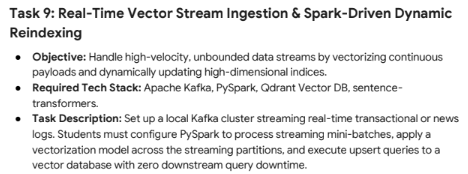

In [ ]:
!pip install sentence-transformers scikit-learn matplotlib

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully!
New message: Robot detected abnormal vibration
Vector added | Dimension: 384
New message: Production line temperature increased
Vector added | Dimension: 384
New message: Robot completed assembly
Vector added | Dimension: 384
New message: Machine requires maintenance
Vector added | Dimension: 384
New message: Camera detected defective product
Vector added | Dimension: 384
New message: Robot battery level is low
Vector added | Dimension: 384
New message: Motor temperature is high
Vector added | Dimension: 384
New message: Production line is working normally
Vector added | Dimension: 384

Search Query:
Which machine needs repair?

Top Matching Results:
----------------------------
Score: 0.691
Message: Machine requires maintenance

Score: 0.363
Message: Robot completed assembly

Score: 0.309
Message: Production line is working normally



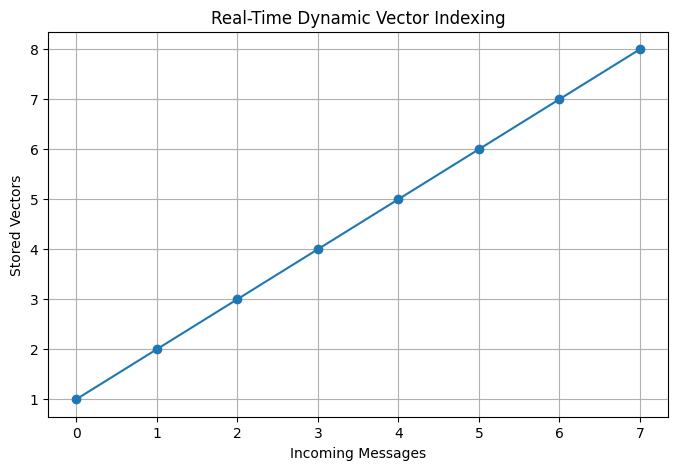

In [ ]:
import time
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


# 1. Load embedding model

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")


# 2. Simulated real-time factory data

messages = [
    "Robot detected abnormal vibration",
    "Production line temperature increased",
    "Robot completed assembly",
    "Machine requires maintenance",
    "Camera detected defective product",
    "Robot battery level is low",
    "Motor temperature is high",
    "Production line is working normally"
]


# 3. Vector storage

vector_database = []
text_database = []

vector_count = []


# 4. Simulate streaming

for message in messages:

    print("New message:", message)

    # Convert message to vector
    vector = model.encode(message)

    # Store vector
    vector_database.append(vector)

    # Store original text
    text_database.append(message)

    vector_count.append(
        len(vector_database)
    )

    print(
        "Vector added | Dimension:",
        len(vector)
    )

    time.sleep(0.5)


# 5. Semantic search

query = "Which machine needs repair?"

print("\nSearch Query:")
print(query)


# Convert query into vector
query_vector = model.encode(query)


# Calculate similarity
scores = cosine_similarity(
    [query_vector],
    vector_database
)[0]


# Get top 3 results
top_results = scores.argsort()[-3:][::-1]


print("\nTop Matching Results:")
print("----------------------------")


for index in top_results:

    print(
        f"Score: {scores[index]:.3f}"
    )

    print(
        "Message:",
        text_database[index]
    )

    print()


# 6. Graph — Dynamic vector indexing

plt.figure(figsize=(8, 5))

plt.plot(
    vector_count,
    marker="o"
)

plt.xlabel(
    "Incoming Messages"
)

plt.ylabel(
    "Stored Vectors"
)

plt.title(
    "Real-Time Dynamic Vector Indexing"
)

plt.grid()

plt.show()